In [6]:
import os

files_needed = {
    "Model"     : "../models/best_model.pt",
    "Vocab"     : "../data/vocab.json",
    "Sequences" : "../data/sequences.pt",
    "Attacks"   : "../data/attack_traffic.csv",
}

print("=== Checking Required Files ===\n")
all_good = True
for name, path in files_needed.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e6 if exists else 0
    status = f"✅ Found ({size:.1f} MB)" if exists else "❌ MISSING"
    print(f"{name:<12}: {status}")
    if not exists:
        all_good = False

print(f"\n{'✅ All files ready!' if all_good else '❌ Fix missing files first!'}")

=== Checking Required Files ===

Model       : ✅ Found (39.1 MB)
Vocab       : ✅ Found (0.0 MB)
Sequences   : ✅ Found (256.0 MB)
Attacks     : ✅ Found (121.0 MB)

✅ All files ready!



🚀 Phase 6: Inference & Anomaly Detection
   Device: cpu

✅ Vocab loaded: 38 tokens

STEP 1 — Loading Trained Model
✅ Checkpoint loaded!
   Saved at epoch : 19
   Best val loss  : 0.5405
✅ Model loaded & set to eval mode!
   Device : cpu

📦 Loading normal sequences...
✅ Normal sample: 10,000 sequences

STEP 4 — Calibrating Anomaly Threshold
   Using 10,000 normal sequences
   Percentile target: 99th
   Scoring 10,000 sequences in batches of 128...
   Progress: 63.3% — 6,400 sequences scored

📊 Normal Traffic Score Statistics:
   Mean score  : 0.5828
   Std score   : 1.0406
   Min score   : 0.0002
   Max score   : 5.0133

🎯 Threshold (99th percentile): 3.2565
   → Any score above 3.2565 = ATTACK

💾 Threshold saved → C:\Users\Rushikesh\PROJECTS\can_bus_ids_project\models\threshold.json

STEP 5 — Building Attack Sequences


C:\Users\Rushikesh\PROJECTS\can_bus_ids_project\src\inference.py:265: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


✅ Built 5,000 attack sequences

STEP 6 — Evaluating Detection Performance
Scoring attack sequences...
   Scoring 5,000 sequences in batches of 128...
Scoring normal sequences (sample)...
   Scoring 5,000 sequences in batches of 128...

📊 Detection Results:
   Threshold          : 3.2565
   ─────────────────────────────────
   Attacks detected   : 0/5000 (0.0%)
   Attacks missed     : 5000/5000
   Normal correct     : 4952/5000
   False alarms       : 48/5000 (1.0%)
   ─────────────────────────────────
   Precision          : 0.0000
   Recall             : 0.0000
   F1 Score           : 0.0000

STEP 7 — Plotting Results


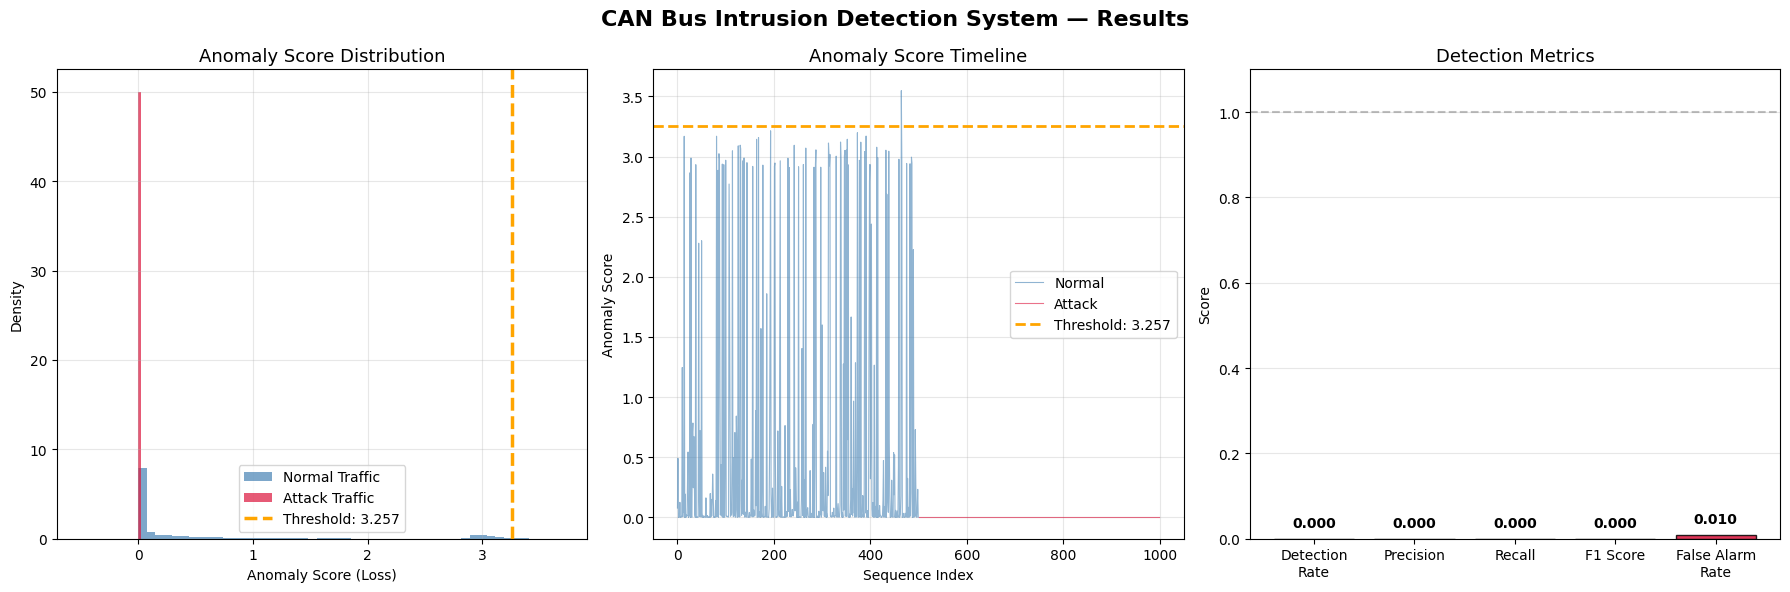

✅ Results chart saved → C:\Users\Rushikesh\PROJECTS\can_bus_ids_project\data\detection_results.png

🎉 Phase 6 Complete!
✅ Threshold saved → C:\Users\Rushikesh\PROJECTS\can_bus_ids_project\models\threshold.json
✅ Results chart   → C:\Users\Rushikesh\PROJECTS\can_bus_ids_project\data/detection_results.png

➡️  Ready for Phase 7: Dashboard!


In [7]:
%run ../src/inference.py

In [8]:
import sys
sys.path.append('../src')
import json, torch
from inference import load_model, detect_single_sequence

# Load vocab and model
with open("../data/vocab.json") as f:
    vocab = json.load(f)

with open("../models/threshold.json") as f:
    threshold_data = json.load(f)

threshold = threshold_data['threshold']
model     = load_model("../models/best_model.pt", len(vocab))

print(f"✅ Threshold loaded: {threshold:.4f}")

# Test with a normal sequence (first 64 IDs from normal data)
import pandas as pd
normal_sample = pd.read_csv(
    "../data/normal_traffic.csv", nrows=64
)
normal_ids = normal_sample['ID'].astype(str).tolist()
score, result = detect_single_sequence(
    model, normal_ids, vocab, threshold
)


STEP 1 — Loading Trained Model
✅ Checkpoint loaded!
   Saved at epoch : 19
   Best val loss  : 0.5405
✅ Model loaded & set to eval mode!
   Device : cpu
✅ Threshold loaded: 3.2565

Single Sequence Detection
Anomaly Score : 0.0013
Threshold     : 3.2565
Result        : ✅ NORMAL


In [9]:
# Test with attack data
attack_sample = pd.read_csv(
    "../data/attack_traffic.csv",
    header=None,
    names=['Timestamp','ID','DLC','D0','D1',
           'D2','D3','D4','D5','D6','D7','Flag'],
    nrows=64
)
attack_ids = attack_sample['ID'].astype(str).tolist()
score, result = detect_single_sequence(
    model, attack_ids, vocab, threshold
)


Single Sequence Detection
Anomaly Score : 18.8893
Threshold     : 3.2565
Result        : 🚨 ATTACK DETECTED


In [10]:
import json

with open("../models/threshold.json") as f:
    t = json.load(f)

print("=== Threshold Configuration ===\n")
for key, val in t.items():
    print(f"  {key:<15} : {val}")

=== Threshold Configuration ===

  threshold       : 3.2565481662750244
  percentile      : 99
  mean_normal     : 0.5828427672386169
  std_normal      : 1.0406482219696045
  min_normal      : 0.00017947214655578136
  max_normal      : 5.013270378112793
  num_samples     : 10000
